<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/ml_recap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1 : 양성종양
2 : 양성종양
3 : 양성종양
4 : 양성종양
5 : 악성종양
6 : 악성종양
7 : 악성종양
8 : 악성종양


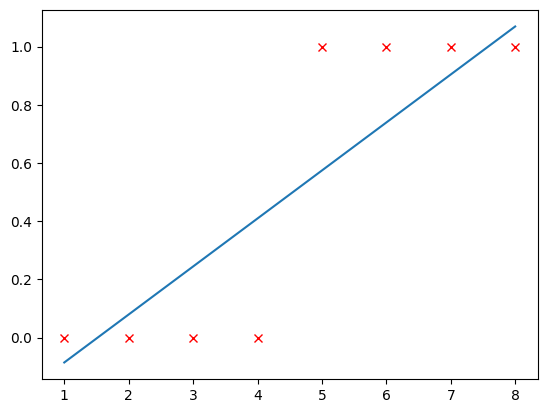

In [6]:
import matplotlib.pyplot as  plt
import numpy as np

class Neuron:

    def __init__(self):
        self.w = 1.0     # 가중치를 초기화합니다
        self.b = 1.0     # 절편을 초기화합니다

    def forpass(self, x):
        y_hat = x * self.w + self.b       # 직선 방정식을 계산합니다
        return y_hat

    def backprop(self, x, err):
        w_grad = x * err    # 가중치에 대한 그래디언트를 계산합니다
        b_grad = 1 * err    # 절편에 대한 그래디언트를 계산합니다
        return w_grad, b_grad

    def activation(self, z):
        return z

    def fit(self, x, y, epochs=200):
        for i in range(epochs):           # 에포크만큼 반복합니다
            for x_i, y_i in zip(x, y):    # 모든 샘플에 대해 반복합니다
                y_hat = self.forpass(x_i) # 정방향 계산
                y_hat = self.activation(y_hat)
                err = y_hat - y_i      # 오차 계산
                w_grad, b_grad = self.backprop(x_i, err)  # 역방향 계산
                self.w -= 0.01*w_grad          # 가중치 업데이트
                self.b -= 0.01*b_grad          # 절편 업데이트

x = np.array([1,2,3,4,5,6,7,8])
y = np.array([0,0,0,0,1,1,1,1])
# x = np.array([1,2,3,4,5,6,7,8,12])
# y = np.array([0,0,0,0,1,1,1,1,1])

neuron = Neuron()
neuron.fit(x, y)

for xi, yi in zip(x,y):
    plt.plot(xi,yi,"rx")

y_temp = []
for x_i in x:
    y_hat = neuron.forpass(x_i)
    if( y_hat >= 0.5 ):
        print("%d : 악성종양"%x_i)
    else:
        print("%d : 양성종양"%x_i)
    y_temp.append(y_hat)

plt.plot(x,y_temp)
plt.show()

#로지스틱 회귀 그대로 사용하며 안된다. 이사이에 따라서 결정경계가 흔들리다. -> 시그모이드 함수

### 오즈비 그래프

In [1]:
import numpy as np
probs = np.arange(0, 1, 0.01)

print(type(probs))
print(probs.ndim)
print(probs.shape)
print(probs)

<class 'numpy.ndarray'>
1
(100,)
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]


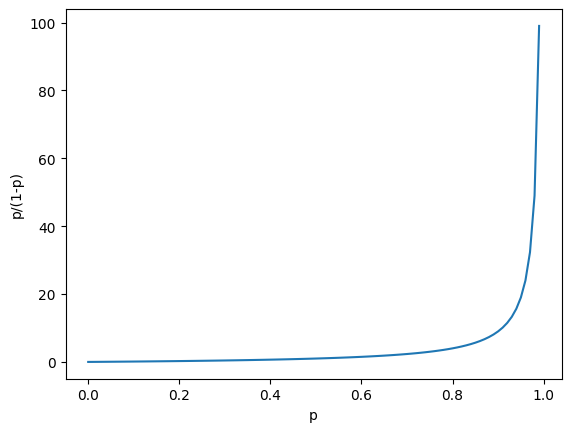

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
probs = np.arange(0, 1, 0.01)
odds = [p/(1-p) for p in probs]
plt.plot(probs, odds)
plt.xlabel('p')
plt.ylabel('p/(1-p)')
plt.show()

### 로짓 그래프

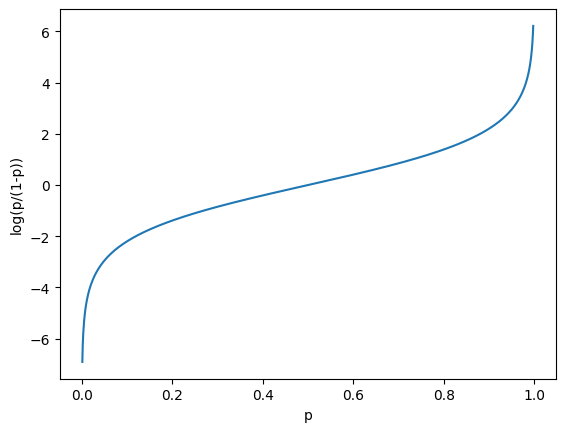

In [3]:
probs  = np.arange(0.001, 0.999, 0.001)
logit = [np.log(p/(1-p)) for p in probs]
plt.plot(probs, logit)
plt.xlabel('p')
plt.ylabel('log(p/(1-p))')
plt.show()

### 시그모이드 그래프

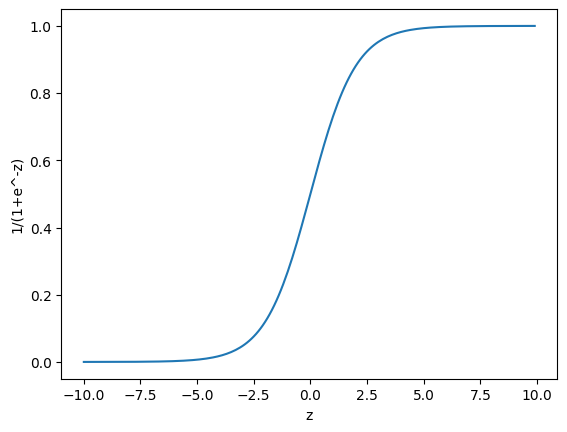

In [4]:
zs = np.arange(-10., 10., 0.1)
gs = [1/(1+np.exp(-z)) for z in zs]
plt.plot(zs, gs)
plt.xlabel('z')
plt.ylabel('1/(1+e^-z)')
plt.show()

### 로지스틱 회귀 구현

1 : 양성종양
2 : 양성종양
3 : 양성종양
4 : 양성종양
5 : 악성종양
6 : 악성종양
7 : 악성종양
8 : 악성종양
30 : 악성종양


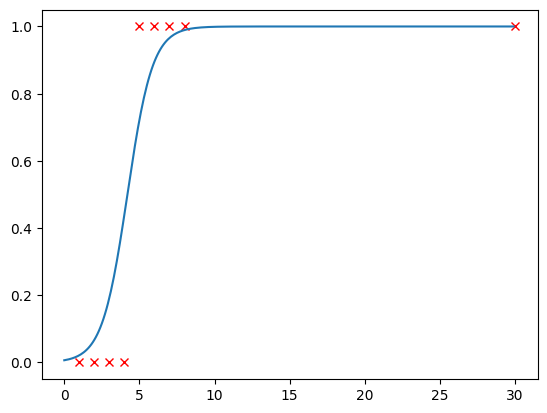

In [7]:
import matplotlib.pyplot as  plt
import numpy as np

class Neuron:

    def __init__(self):
        self.w = 1.0     # 가중치를 초기화합니다
        self.b = 1.0     # 절편을 초기화합니다

    def forpass(self, x):
        z = x * self.w + self.b       # 직선 방정식을 계산합니다
        return z

    def backprop(self, x, err):
        w_grad = x * err    # 가중치에 대한 그래디언트를 계산합니다
        b_grad = 1 * err    # 절편에 대한 그래디언트를 계산합니다
        return w_grad, b_grad

    def activation(self, z):
#         a = z;
        a = 1/(1+np.exp(-z))
        return a

    def fit(self, x, y, epochs=200):
        for i in range(epochs):           # 에포크만큼 반복합니다
            for x_i, y_i in zip(x, y):    # 모든 샘플에 대해 반복합니다
                z = self.forpass(x_i) # 정방향 계산
                a = self.activation(z)
                err = a - y_i       # 오차 계산
                w_grad, b_grad = self.backprop(x_i, err)  # 역방향 계산
                self.w -= 0.01*w_grad          # 가중치 업데이트
                self.b -= 0.01*b_grad          # 절편 업데이트

# x = np.array([1,2,3,4,5,6,7,8])
# y = np.array([0,0,0,0,1,1,1,1])
x = np.array([1,2,3,4,5,6,7,8, 30])
y = np.array([0,0,0,0,1,1,1,1,1])

neuron = Neuron()
neuron.fit(x, y, epochs=1000)

for xi, yi in zip(x,y):
    plt.plot(xi,yi,"rx")

for x_i in x:
    y_hat = neuron.forpass(x_i)
    a = neuron.activation(y_hat)
    if( a >= 0.5 ):
        print("%d : 악성종양"%x_i)
    else:
        print("%d : 양성종양"%x_i)
    y_temp.append(a)

x = np.arange(0,x[-1],0.1)
y_temp = []

for i, x_i in enumerate(x):
    y_hat = neuron.forpass(x_i)
    a = neuron.activation(y_hat)
    y_temp.append(a)

plt.plot(x,y_temp)
plt.show()

### 로그 그래프

In [ ]:
zs = np.arange(0.01, 10., 0.01)
gs = [np.log(z) for z in zs]
plt.plot(zs, gs)
plt.xlim(0,1)
plt.ylim(-5,0)
plt.xlabel('z')
plt.ylabel('(-np.log(z)')
plt.show()

In [ ]:
zs = np.arange(0.01, 10., 0.01)
gs = [-np.log(z) for z in zs]
plt.plot(zs, gs)
plt.xlim(0,1)
plt.ylim(0,5)
plt.xlabel('z')
plt.ylabel('(-np.log(z)')
plt.show()

In [ ]:
zs = np.arange(0.01, 0.99, 0.01)
gs = [-np.log(1-z) for z in zs]
plt.plot(zs, gs)
plt.xlim(0,1)
plt.ylim(0,5)
plt.xlabel('z')
plt.ylabel('-(np.log(1-z)')
plt.show()

In [8]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print(cancer.data.shape, cancer.target.shape)

(569, 30) (569,)


In [ ]:
print(cancer.data[:3])

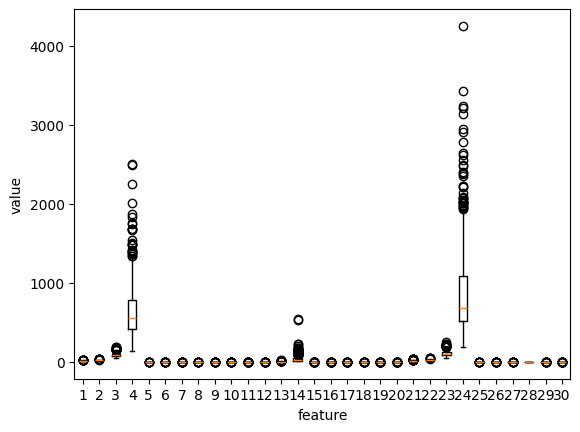

In [9]:
import matplotlib.pyplot as  plt
import numpy as np
plt.boxplot(cancer.data)
plt.xlabel('feature')
plt.ylabel('value')
plt.show()

In [10]:
cancer.feature_names[[3,23]]

array(['mean area', 'worst area'], dtype='<U23')

In [11]:
cancer.target #정답

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [12]:
np.unique(cancer.target, return_counts=True)

(array([0, 1]), array([212, 357]))

In [13]:
x = cancer.data
print(x.shape) # 샘플 수, 특성 수
y = cancer.target
print(y.ndim)

(569, 30)
1


In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y,
test_size=0.2, random_state=42)

In [15]:
print(x_train.shape, x_test.shape)

(455, 30) (114, 30)


In [ ]:
np.unique(y_train, return_counts=True)

In [16]:
a = np.zeros((5,6))
print(a)
print(a.shape)

b = np.ones((5,6))
print(b)
print(b.shape)

c = np.full((5,6), 7)
print(c)
print(c.shape)

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
(5, 6)
[[1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1.]]
(5, 6)
[[7 7 7 7 7 7]
 [7 7 7 7 7 7]
 [7 7 7 7 7 7]
 [7 7 7 7 7 7]
 [7 7 7 7 7 7]]
(5, 6)


In [17]:
a = np.arange(4)
print(a.ndim)
print(a.shape)
print(len(a)) # a.shape[0]
print(a[0])
print(a[0].shape) # scalar 0차원

1
(4,)
4
0
()


In [ ]:
# print(np.arange(4))
a = np.arange(4).reshape(2,2)
print(a)
print(len(a))
print(a.shape)
print(a.shape[0]) # number of element, length
print(a[0])
print(a[0].ndim)
print(a[0].shape)

#### list의 연산

In [18]:
x = [1,2,3,4,5,6,7,8]
w = [1,1,1,1]
print(x+w)

[1, 2, 3, 4, 5, 6, 7, 8, 1, 1, 1, 1]


#### 배열의 연산

In [19]:
x = np.array([1,2,3,4])
w = np.array([3,4,5,6])
print(x+w)

[ 4  6  8 10]


#### 브로드 캐스트(broadcast) 연산 - 수학적으로 리피트(Repeat) 연산

In [20]:
x = np.array([1,2,3,4])
a = 3   # => [3,3,3,3]
print(x*a) #저차원이 고차원으로 변형됨

[ 3  6  9 12]


In [21]:
x = np.array([1,2,3,4])
w = np.array([3,4,5,6])
print(x*w)
b = 3
c = np.sum(x*w)+3
print(c)

[ 3  8 15 24]
53


In [22]:
y_hat=53
y=50
x = np.array([1,2,3,4])
err = y_hat - y
w_grad = x*err  # [1,2,3,4]*[3,3,3,3]
print(w_grad)

[ 3  6  9 12]


In [23]:
a = np.arange(10)
print(a)
z = np.clip(a, 5, None) #min, max
print(z)
z = np.clip(a, None, 7)
print(z)
z = np.clip(a, 3, 7)
print(z)

# np.exp(1000) -> infinite overfow
z = -100
np.exp(-z)

[0 1 2 3 4 5 6 7 8 9]
[5 5 5 5 5 5 6 7 8 9]
[0 1 2 3 4 5 6 7 7 7]
[3 3 3 3 4 5 6 7 7 7]


np.float64(2.6881171418161356e+43)

In [24]:
class LogisticNeuron:

    def __init__(self):
        self.w = None
        self.b = None

    def forpass(self, x):
        z = np.sum(x * self.w) + self.b  # 직선 방정식을 계산합니다
        return z

    def backprop(self, x, err):
        w_grad = x * err    # 가중치에 대한 그래디언트를 계산합니다
        b_grad = 1 * err    # 절편에 대한 그래디언트를 계산합니다
        return w_grad, b_grad

    def activation(self, z):
        z = np.clip(z, -100, None) # 안전한 np.exp() 계산을 위해
        a = 1 / (1 + np.exp(-z))  # 시그모이드 계산
        return a

    def fit(self, x, y, epochs=100, lr=0.01):  # x.shape => (455,30)
        self.w = np.ones(x.shape[1])      # 가중치를 초기화합니다.  w.shape => (30,)
        print('self.w=', self.w)
        self.b = 0                        # 절편을 초기화합니다.
        print('self.b=', self.b)
        for i in range(epochs):           # epochs만큼 반복합니다
            for x_i, y_i in zip(x, y):    # 모든 샘플에 대해 반복합니다
#                 print(x_i.shape)          # x_i.shape => (30,)
                z = self.forpass(x_i)     # 정방향 계산
#                 print(z.shape)            # ()
#                 print(z)
                a = self.activation(z)    # 활성화 함수 적용
#                 print(a.shape)
#                 print(a)
                err = (a - y_i)          # 오차 계산
#                 print(err.shape)         # ()
#                 print(err)
                w_grad, b_grad = self.backprop(x_i, err) # 역방향 계산
#                 print(w_grad.shape)
                self.w -= lr*w_grad          # 가중치 업데이트
                self.b -= lr*b_grad          # 절편 업데이트
#                 break
#             break

    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]    # 정방향 계산
        a = self.activation(np.array(z))        # 활성화 함수 적용
        return a >= 0.5

In [25]:
print(x_train.shape)
print(y_train.shape)

(455, 30)
(455,)


In [26]:
neuron = LogisticNeuron()
neuron.fit(x_train, y_train)
print('self.w=', neuron.w)
print('self.b=', neuron.b)

self.w= [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
self.b= 0
self.w= [ 4.53740939e+01  3.80077777e+00  2.24911354e+02  4.00809256e+01
  1.12247740e+00 -3.08758680e-01 -1.27870087e+00  1.10409322e-01
  1.02849701e+00  1.16716898e+00  1.30750870e+00  2.39291404e+00
 -2.96841970e+00 -8.23137065e+01  9.80782768e-01  5.94952276e-01
  4.40234563e-01  8.82845327e-01  9.02861580e-01  9.68399147e-01
  4.63922456e+01 -1.32762598e+00  1.88704663e+02 -8.89952473e+01
  9.87081791e-01 -3.86857801e+00 -5.24016534e+00 -6.66624468e-01
  1.47744304e-01  8.28933878e-01]
self.b= 5.675968589790766


In [27]:
# print(neuron.predict(x_test))
print(neuron.predict(x_test) == y_test)

[ True  True  True False  True False  True  True  True  True  True  True
  True  True  True False False  True False  True  True  True  True  True
 False False  True  True  True False  True  True  True  True  True False
  True  True False  True  True  True  True  True  True False  True  True
  True  True  True False  True  True  True  True  True  True  True  True
 False  True  True False  True  True False  True False False  True  True
  True  True  True  True False  True  True False False  True  True  True
  True  True False  True False False False False  True  True  True  True
  True  True  True False  True  True False  True  True  True  True  True
  True  True False  True False  True]


In [28]:
np.mean(neuron.predict(x_test) == y_test) #acurracy

np.float64(0.7456140350877193)

### 단일층 신경망 구현

In [31]:
x = np.array([10,20,30,40,50,60,70,80,90])
y = np.array([ 0, 1, 1, 0, 0, 1, 1, 0, 1])
print(np.arange(len(x)))
indexes = np.random.permutation(len(x)) #인덱스 순서를 섞어준다
print(indexes)
print(x[indexes])  # x[ [2 4 7 5 8 3 0 1 6] ]
print(y[indexes])

[0 1 2 3 4 5 6 7 8]
[1 8 6 7 4 0 3 5 2]
[20 90 70 80 50 10 40 60 30]
[1 1 1 0 0 0 0 1 1]


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y,
                                                    test_size=0.2, random_state=42)

class SingleLayer:

    def __init__(self, rand_flag=0):
        self.w = None
        self.b = None
        self.losses = []
        self.rand_flag = rand_flag
        self.rate = 0.01

    def forpass(self, x):
        z = np.sum(x * self.w) + self.b  # 직선 방정식을 계산합니다
        return z

    def backprop(self, x, err):
        w_grad = x * err    # 가중치에 대한 그래디언트를 계산합니다
        b_grad = 1 * err    # 절편에 대한 그래디언트를 계산합니다
        return w_grad, b_grad

    def activation(self, z):
        z = np.clip(z, -100, None) # 안전한 np.exp() 계산을 위해
        a = 1 / (1 + np.exp(-z))  # 시그모이드 계산
        return a

    def fit(self, x, y, epochs=100):
        self.w = np.ones(x.shape[1])               # 가중치를 초기화합니다.
        self.b = 0                                 # 절편을 초기화합니다.
        for i in range(epochs):                    # epochs만큼 반복합니다
            loss = 0
            # 인덱스를 섞습니다

            if( self.rand_flag == 1 ):
                indexes = np.random.permutation(len(x))
            else:
                indexes = np.arange(len(x))

            for i in indexes:                      # 모든 샘플에 대해 반복합니다
                z = self.forpass(x[i])             # 정방향 계산
                a = self.activation(z)             # 활성화 함수 적용
                err = a - y[i]                     # 오차 계산
                w_grad, b_grad = self.backprop(x[i], err) # 역방향 계산
                self.w -= self.rate*w_grad                   # 가중치 업데이트,  SGD 알고리즘
                self.b -= self.rate*b_grad                   # 절편 업데이트
                # 안전한 로그 계산을 위해 클리핑한 후 손실을 누적합니다
                a = np.clip(a, 1e-10, 1-1e-10)
                loss += -(y[i]*np.log(a)+(1-y[i])*np.log(1-a))
            # 에포크마다 평균 손실을 저장합니다
            self.losses.append(loss/len(y))

    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]     # 정방향 계산
        return np.array(z) > 0                   # 스텝 함수 적용

    def score(self, x, y):
        return np.mean(self.predict(x) == y)

layer1 = SingleLayer(rand_flag=0)
layer1.fit(x_train, y_train,1000)
print(layer1.score(x_test, y_test))

layer2 = SingleLayer(rand_flag=1) #인덱스도 편향을 만들 수 있어서, 에포크마다 섞어주는게 좋다
layer2.fit(x_train, y_train,1000)
print(layer2.score(x_test, y_test))

0.8157894736842105
0.9385964912280702


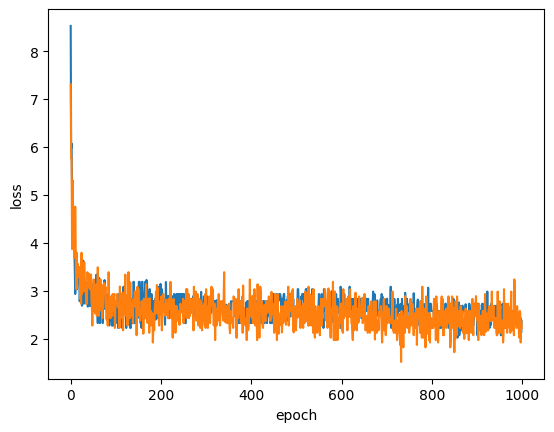

In [30]:
plt.plot(layer1.losses)
plt.plot(layer2.losses)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

### 스케일 테스트

In [32]:
x_train = np.arange(10).reshape(10,1)
x_train = x_train*1000
print(x_train)
train_mean = np.mean(x_train, axis=0)
print(train_mean)
train_std = np.std(x_train, axis=0)
print(train_std)
x_train_scaled = (x_train - train_mean) / train_std
print(x_train_scaled)
print(np.mean(x_train_scaled, axis=0))
print(np.std(x_train_scaled, axis=0))

[[   0]
 [1000]
 [2000]
 [3000]
 [4000]
 [5000]
 [6000]
 [7000]
 [8000]
 [9000]]
[4500.]
[2872.28132327]
[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]
[-4.4408921e-17]
[1.]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
cancer = load_breast_cancer()

x = cancer.data
y = cancer.target
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y,
                                                            test_size=0.2, random_state=42)
print(cancer.feature_names[[2,3]])
plt.boxplot(x_train[:, 2:4])
plt.xlabel('feature')
plt.ylabel('value')
plt.show()

In [ ]:
a = np.arange(1,11)
print(a.shape)
a *= 123
print(a)
print(np.mean(a))
print(np.std(a))

a = (a - np.mean(a)) / np.std(a)
print(a)
print(np.mean(a))
print(np.std(a))

In [ ]:
a = np.array([[1,2,3],
              [4,5,6]])
print(a.shape)     # (2,3)
print(np.sum(a))   # ()
print(np.sum(a, axis=0)) # 행끼리 더하라.  , 세로로 더하라  (3,)
print(np.sum(a, axis=1)) # 열끼리 더하라.  , 가로로 더하라  (2,)

In [ ]:
a = np.array([[1,400],
              [2,300],
              [3,500]])
print(a.shape)
train_mean = np.mean(a, axis=0)
train_std = np.std(a, axis=0)
a_scaled = (a - train_mean) / train_std
print(a_scaled)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train_all, x_test, y_train_all, y_test = train_test_split(x, y, stratify=y,
                                                            test_size=0.2, random_state=42)

x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all,
                                                  test_size=0.2, random_state=42)
print(len(x_train), len(x_val))

In [ ]:
class SingleLayer:

    def __init__(self, learning_rate=0.1, l1=0, l2=0):
        self.w = None
        self.b = None
        self.losses = []
        self.val_losses = []
        self.w_history = []
        self.lr = learning_rate
        self.l1 = l1
        self.l2 = l2

    def forpass(self, x):
        z = np.sum(x * self.w) + self.b    # 직선 방정식을 계산합니다
        return z

    def backprop(self, x, err):
        w_grad = x * err          # 가중치에 대한 그래디언트를 계산합니다
        b_grad = 1 * err    # 절편에 대한 그래디언트를 계산합니다
        return w_grad, b_grad

    def activation(self, z):
        z = np.clip(z, -100, None) # 안전한 np.exp() 계산을 위해
        a = 1 / (1 + np.exp(-z))  # 시그모이드 계산
        return a

    def fit(self, x, y, epochs=100, x_val=None, y_val=None):
        self.w = np.ones(x.shape[1])               # 가중치를 초기화합니다.
        self.b = 0                                 # 절편을 초기화합니다.
        self.w_history.append(self.w.copy())       # 가중치를 기록합니다.
        np.random.seed(42)                         # 랜덤 시드를 지정합니다.
        for i in range(epochs):                    # epochs만큼 반복합니다.
            loss = 0
            # 인덱스를 섞습니다
            indexes = np.random.permutation(np.arange(len(x)))
            for i in indexes:                      # 모든 샘플에 대해 반복합니다
                z = self.forpass(x[i])             # 정방향 계산
                a = self.activation(z)             # 활성화 함수 적용
                err = (a - y[i])                  # 오차 계산
                w_grad, b_grad = self.backprop(x[i], err) # 역방향 계산
                # 그래디언트에서 페널티 항의 미분 값을 더합니다
                w_grad += self.l1 * np.sign(self.w) + self.l2 * self.w
                self.w -= self.lr * w_grad         # 가중치 업데이트
                self.b -= b_grad                   # 절편 업데이트
                # 가중치를 기록합니다.
                self.w_history.append(self.w.copy())
                # 안전한 로그 계산을 위해 클리핑한 후 손실을 누적합니다
                a = np.clip(a, 1e-10, 1-1e-10)
                loss += -(y[i]*np.log(a)+(1-y[i])*np.log(1-a))
            # 에포크마다 평균 손실을 저장합니다
            self.losses.append(loss/len(y) + self.reg_loss())
            # 검증 세트에 대한 손실을 계산합니다
            self.update_val_loss(x_val, y_val)

    def predict(self, x):
        z = [self.forpass(x_i) for x_i in x]     # 정방향 계산
        return np.array(z) >= 0                   # 스텝 함수 적용

    def score(self, x, y):
        return np.mean(self.predict(x) == y)

    def reg_loss(self):
        return self.l1 * np.sum(np.abs(self.w)) + self.l2 / 2 * np.sum(self.w**2)

    def update_val_loss(self, x_val, y_val):
        if x_val is None:
            return
        val_loss = 0
        for i in range(len(x_val)):
            z = self.forpass(x_val[i])     # 정방향 계산
            a = self.activation(z)         # 활성화 함수 적용
            a = np.clip(a, 1e-10, 1-1e-10)
            val_loss += -(y_val[i]*np.log(a)+(1-y_val[i])*np.log(1-a))
        self.val_losses.append(val_loss/len(y_val) + self.reg_loss())

In [ ]:
layer1 = SingleLayer()
layer1.fit(x_train, y_train)
layer1.score(x_val, y_val)

In [ ]:
w2 = []
w3 = []
for w in layer1.w_history:
    w2.append(w[2])
    w3.append(w[3])
plt.plot(w2, w3)
plt.plot(w2[-1], w3[-1], 'ro')
plt.xlabel('w[2]')
plt.ylabel('w[3]')
plt.show()

In [ ]:
train_mean = np.mean(x_train, axis=0)
train_std = np.std(x_train, axis=0)
x_train_scaled = (x_train - train_mean) / train_std

In [ ]:
layer2 = SingleLayer()
layer2.fit(x_train_scaled, y_train)

In [ ]:
w2 = []
w3 = []
for w in layer2.w_history:
    w2.append(w[2])
    w3.append(w[3])
plt.plot(w2, w3)
plt.plot(w2[-1], w3[-1], 'ro')
plt.xlabel('w[2]')
plt.ylabel('w[3]')
plt.show()

In [ ]:
layer2.score(x_val, y_val)

In [ ]:
val_mean = np.mean(x_val, axis=0)
val_std = np.std(x_val, axis=0)
x_val_scaled = (x_val - val_mean) / val_std

In [ ]:
layer2.score(x_val_scaled, y_val)

In [ ]:
x_val_scaled = (x_val - train_mean) / train_std

In [ ]:
layer2.score(x_val_scaled, y_val)

In [ ]:
layer3 = SingleLayer()
layer3.fit(x_train_scaled, y_train, x_val=x_val_scaled, y_val=y_val)
plt.ylim(0, 0.3)
plt.plot(layer3.losses)
plt.plot(layer3.val_losses)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

In [ ]:
l1_list = [0.0001, 0.001, 0.01]

for l1 in l1_list:
    lyr = SingleLayer(l1=l1)
    lyr.fit(x_train_scaled, y_train, x_val=x_val_scaled, y_val=y_val)

    plt.plot(lyr.losses)
    plt.plot(lyr.val_losses)
    plt.title('Learning Curve (l1={})'.format(l1))
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train_loss', 'val_loss'])
    plt.ylim(0, 0.3)
    plt.show()

    plt.plot(lyr.w, 'bo')
    plt.title('Weight (l1={})'.format(l1))
    plt.ylabel('value')
    plt.xlabel('weight')
    plt.ylim(-4, 4)
    plt.show()

In [ ]:
l2_list = [0.0001, 0.001, 0.01]

for l2 in l2_list:
    lyr = SingleLayer(l2=l2)
    lyr.fit(x_train_scaled, y_train, x_val=x_val_scaled, y_val=y_val)

    plt.plot(lyr.losses)
    plt.plot(lyr.val_losses)
    plt.title('Learning Curve (l2={})'.format(l2))
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train_loss', 'val_loss'])
    plt.ylim(0, 0.3)
    plt.show()

    plt.plot(lyr.w, 'bo')
    plt.title('Weight (l2={})'.format(l2))
    plt.ylabel('value')
    plt.xlabel('weight')
    plt.ylim(-4, 4)
    plt.show()

In [ ]:
a = 'hello'+'world'
print(a)
a = (1,2,3)+(4,5,6)
print(a)
a = [1,2,3]+[4,5,6]
print(a)

In [ ]:
a = np.arange(100)
a *= 100
print(a)
start=10
end = 20
val = a[start:end]
print(val)
index = list(range(0, start))+list(range(end, len(a)))
print(index)
# # # b = list(a)
fold = a[np.array(index)]
print(fold)
# fold[0] = 999
# print(fold)
# print(a)



In [ ]:
validation_scores = []
k = 10
bins = len(x_train_all) // k

for i in range(k):
    start = i*bins
    end = (i+1)*bins
    val_fold = x_train_all[start:end]
    val_target = y_train_all[start:end]

    train_index = list(range(0, start))+list(range(end, len(x_train)))
    train_fold = x_train_all[train_index]
    train_target = y_train_all[train_index]
    train_mean = np.mean(train_fold, axis=0)
    train_std = np.std(train_fold, axis=0)
    train_fold_scaled = (train_fold - train_mean) / train_std
    val_fold_scaled = (val_fold - train_mean) / train_std

    lyr = SingleLayer(l2=0.01)
    lyr.fit(train_fold_scaled, train_target, epochs=50)
    score = lyr.score(val_fold_scaled, val_target)
    validation_scores.append(score)

print(np.mean(validation_scores))